<a href="https://colab.research.google.com/github/j2tori-design/Animal-Shelter-Analytics/blob/Model-RandomForest/Model_RandomForest_Euthanasia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 랜덤포레스트 안락사 모델
1. 전처리 데이터 불러오기
2. 직접 모델 (전체 개체 대상) 학습
- Feature importance, 혼동행렬
3. 2단계 모델 (비입양군 대상) 학습
- Feature importance, 혼동행렬
4. 모델 성능 비교

In [ ]:
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

### 1. 전처리 데이터 불러오기

In [ ]:
import pandas as pd

X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_test  = pd.read_csv("y_test.csv").squeeze("columns")
y_euth_train = pd.read_csv("y_euth_train.csv").squeeze("columns")
y_euth_test  = pd.read_csv("y_euth_test.csv").squeeze("columns")

print("X_train:", X_train.shape)
print("안락사 비율 (train):", round(y_euth_train.mean()*100, 2), "%")
print("안락사 개수 (train):", y_euth_train.sum(), "/", len(y_euth_train))

X_train: (98342, 65)
안락사 비율 (train): 6.68 %
안락사 개수 (train): 6571 / 98342


### 2. 모델 학습 - 직접 모델 (전체 개체 대상)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    average_precision_score, roc_auc_score, classification_report
)

# 안락사 예측 - 직접 모델 (전체 개체 대상)
rf_euth = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced',  # 불균형 대응
    random_state=42,
    n_jobs=-1
)
rf_euth.fit(X_train, y_euth_train)

# 예측
y_euth_pred  = rf_euth.predict(X_test)
y_euth_proba = rf_euth.predict_proba(X_test)[:, 1]

# 평가 (불균형이라 Recall + PR-AUC 중심!)
print("=== 안락사 직접 모델 (전체 대상) ===")
print("Recall   :", round(recall_score(y_euth_test, y_euth_pred), 3))
print("Precision:", round(precision_score(y_euth_test, y_euth_pred), 3))
print("F1       :", round(f1_score(y_euth_test, y_euth_pred), 3))
print("PR-AUC   :", round(average_precision_score(y_euth_test, y_euth_proba), 3))
print("ROC-AUC  :", round(roc_auc_score(y_euth_test, y_euth_proba), 3))
print()
print(classification_report(y_euth_test, y_euth_pred, digits=3))

=== 안락사 직접 모델 (전체 대상) ===
Recall   : 0.749
Precision: 0.692
F1       : 0.72
PR-AUC   : 0.744
ROC-AUC  : 0.937

              precision    recall  f1-score   support

           0      0.981     0.975     0.978     22810
           1      0.692     0.749     0.720      1695

    accuracy                          0.960     24505
   macro avg      0.837     0.862     0.849     24505
weighted avg      0.961     0.960     0.960     24505



### feature importance
- 입소시 건강 상태 -> 건강 비정상이면 안락사 위험 큼
- 동물 종 -> 야생동물은 안락사, 방사 비율 높음
- 나이 -> 노령일수록 안락사 위험 큼
- 이름 유무 -> 이름 없는 애 안락사 위험 큼
- 야생 입소
- 성별 모름 -> 성별만의 영향이라기보단 야생동물은 성별 모르는 비율 큼

* 데이터 누수 위험 -> 입소 시점의 데이터만 사용해야 함
* 목적에 따라 중요 변수 다르다 -> 입양 여부에서는 나이/이름이 중요 변수였음

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# importances = pd.Series(rf_euth.feature_importances_, index=X_train.columns)
# top15 = importances.sort_values(ascending=False).head(15)

# # 컬럼명 깔끔하게 정리
# def clean_label(col):
#     col = col.replace('_intake', '')        # Animal Type_intake_Other → Animal Type_Other
#     col = col.replace('Intake Condition_', 'Condition: ')
#     col = col.replace('Intake Type_', 'Intake: ')
#     col = col.replace('Animal Type_', 'Type: ')
#     col = col.replace('sterilized_status_', 'Sterilized: ')
#     col = col.replace('color_grouped_', 'Color: ')
#     col = col.replace('breed_grouped_', 'Breed: ')
#     col = col.replace('sex_', 'Sex: ')
#     col = col.replace('_', ' ')
#     return col

# labels = [clean_label(idx) for idx in top15.index]

# plt.figure(figsize=(9, 6))
# plt.barh(labels[::-1], top15.values[::-1], color='#4C72B0')
# plt.title('Euthanasia Prediction - Feature Importance (Top 15)', fontsize=13, fontweight='bold')
# plt.xlabel('Importance')
# plt.tight_layout()
# plt.savefig("euth_feature_importance.png", dpi=120)
# plt.show()

=== 안락사 예측 Top 15 변수 ===
Intake Condition_Normal         0.0896
Animal Type_intake_Other        0.0833
age_days                        0.0801
has_name                        0.0774
Intake Type_Wildlife            0.0724
sex_Unknown                     0.0711
sterilized_status_Unknown       0.0708
Intake Condition_Injured        0.0445
intake_month                    0.0430
Intake Type_Stray               0.0357
Intake Condition_Sick           0.0279
Animal Type_intake_Dog          0.0210
sex_Male                        0.0194
sterilized_status_Sterilized    0.0128
color_grouped_Other             0.0124
dtype: float64


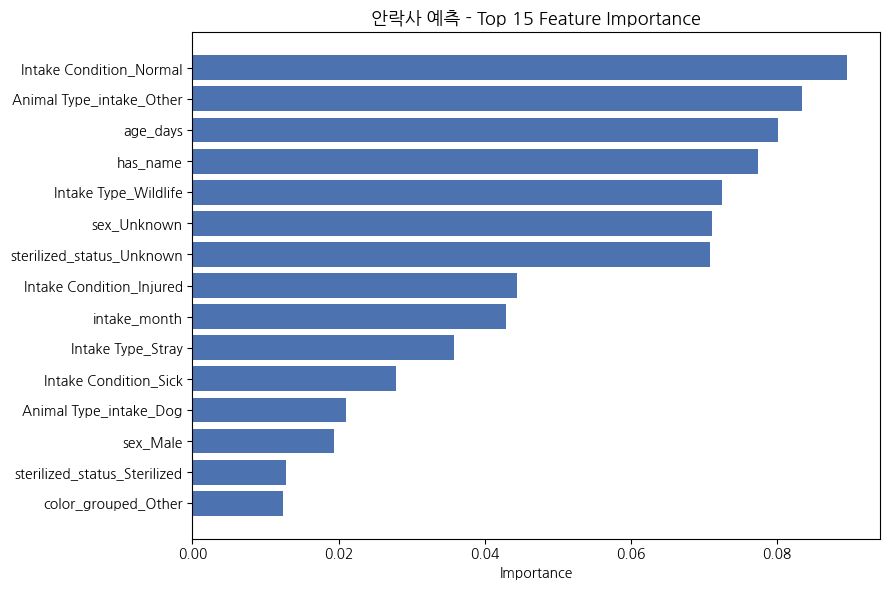

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_euth.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

print("=== 안락사 예측 Top 15 변수 ===")
print(top15.round(4))

plt.figure(figsize=(9, 6))
plt.barh(top15.index[::-1], top15.values[::-1], color='#4C72B0')
plt.title('안락사 예측 - Top 15 Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 혼동행렬

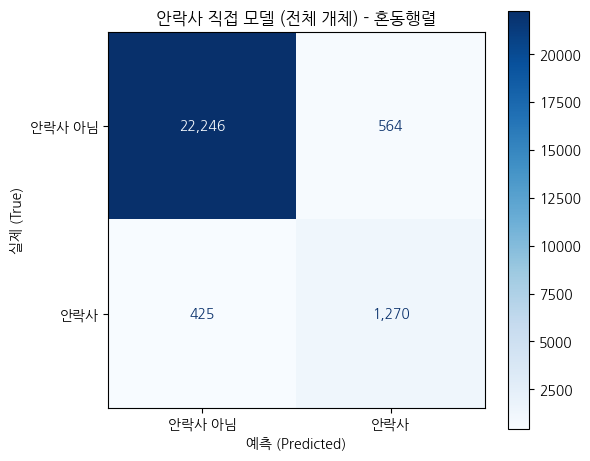

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_direct = confusion_matrix(y_euth_test, y_euth_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_direct, display_labels=['안락사 아님', '안락사']).plot(
    ax=ax, cmap='Blues', values_format=',d', colorbar=True)   # ← 여기 색 바꿈!
ax.set_title('안락사 직접 모델 (전체 개체) - 혼동행렬', fontweight='bold')
ax.set_xlabel('예측 (Predicted)')
ax.set_ylabel('실제 (True)')
ax.grid(False)

plt.tight_layout()
plt.savefig("euth_direct_confusion.png", dpi=120)
plt.show()

### 3. 모델 학습 - 2단계 모델 (비입양군 대상)

In [ ]:
# 2단계 모델: 비입양군(y_train==0)만 필터링
# train에서 비입양만 골라내기
mask_train = (y_train == 0)
mask_test  = (y_test == 0)

X_train_stage2 = X_train[mask_train]
X_test_stage2  = X_test[mask_test]
y_euth_train_stage2 = y_euth_train[mask_train]
y_euth_test_stage2  = y_euth_test[mask_test]

print("2단계 데이터 (비입양군만):")
print("  train:", X_train_stage2.shape, "/ 안락사 비율:", round(y_euth_train_stage2.mean()*100, 2), "%")
print("  test :", X_test_stage2.shape)
print()

# 랜덤포레스트 학습
rf_euth_s2 = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_euth_s2.fit(X_train_stage2, y_euth_train_stage2)

# 예측 + 평가
y_pred_s2  = rf_euth_s2.predict(X_test_stage2)
y_proba_s2 = rf_euth_s2.predict_proba(X_test_stage2)[:, 1]

print("=== 안락사 2단계 모델 (비입양군만) ===")
print("Recall   :", round(recall_score(y_euth_test_stage2, y_pred_s2), 3))
print("Precision:", round(precision_score(y_euth_test_stage2, y_pred_s2), 3))
print("F1       :", round(f1_score(y_euth_test_stage2, y_pred_s2), 3))
print("PR-AUC   :", round(average_precision_score(y_euth_test_stage2, y_proba_s2), 3))
print("ROC-AUC  :", round(roc_auc_score(y_euth_test_stage2, y_proba_s2), 3))

2단계 데이터 (비입양군만):
  train: (54645, 65) / 안락사 비율: 12.02 %
  test : (13561, 65)

=== 안락사 2단계 모델 (비입양군만) ===
Recall   : 0.75
Precision: 0.722
F1       : 0.736
PR-AUC   : 0.775
ROC-AUC  : 0.928


### Feature Importance

=== 안락사 2단계 모델 - Top 15 변수 ===
Animal Type_intake_Other       0.0926
Intake Condition_Normal        0.0851
Intake Type_Wildlife           0.0835
age_days                       0.0785
sterilized_status_Unknown      0.0603
sex_Unknown                    0.0566
has_name                       0.0565
Intake Condition_Injured       0.0504
Intake Type_Stray              0.0473
intake_month                   0.0417
Intake Condition_Sick          0.0274
Animal Type_intake_Dog         0.0233
sex_Male                       0.0199
Intake Type_Owner Surrender    0.0144
color_grouped_Brown            0.0143
dtype: float64


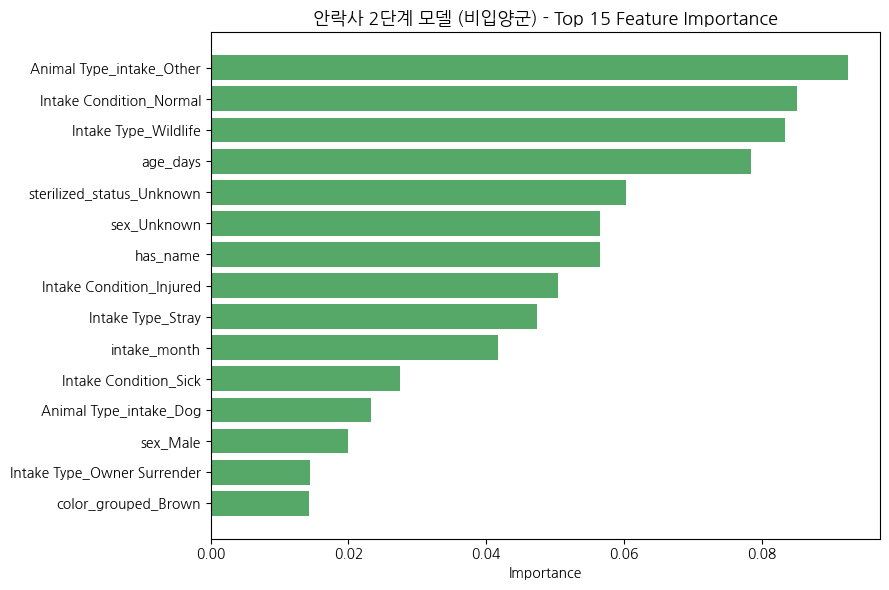

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 2단계 모델 Feature Importance
importances_s2 = pd.Series(rf_euth_s2.feature_importances_, index=X_train.columns)
top15_s2 = importances_s2.sort_values(ascending=False).head(15)

print("=== 안락사 2단계 모델 - Top 15 변수 ===")
print(top15_s2.round(4))

plt.figure(figsize=(9, 6))
plt.barh(top15_s2.index[::-1], top15_s2.values[::-1], color='#55A868')
plt.title('안락사 2단계 모델 (비입양군) - Top 15 Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig("euth_stage2_feature_importance.png", dpi=120)
plt.show()

### 혼동행렬

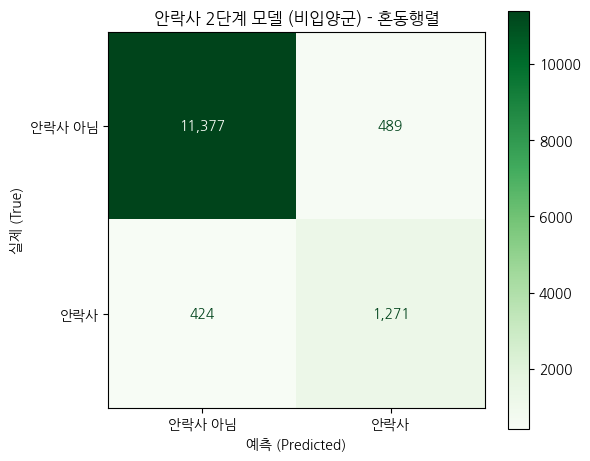

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 2단계 모델 혼동행렬
cm_s2 = confusion_matrix(y_euth_test_stage2, y_pred_s2)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_s2, display_labels=['안락사 아님', '안락사']).plot(
    ax=ax, cmap='Greens', values_format=',d', colorbar=True)
ax.set_title('안락사 2단계 모델 (비입양군) - 혼동행렬', fontweight='bold')
ax.set_xlabel('예측 (Predicted)')
ax.set_ylabel('실제 (True)')
ax.grid(False)

plt.tight_layout()
plt.savefig("euth_stage2_confusion.png", dpi=120)
plt.show()

### 4. 모델 비교

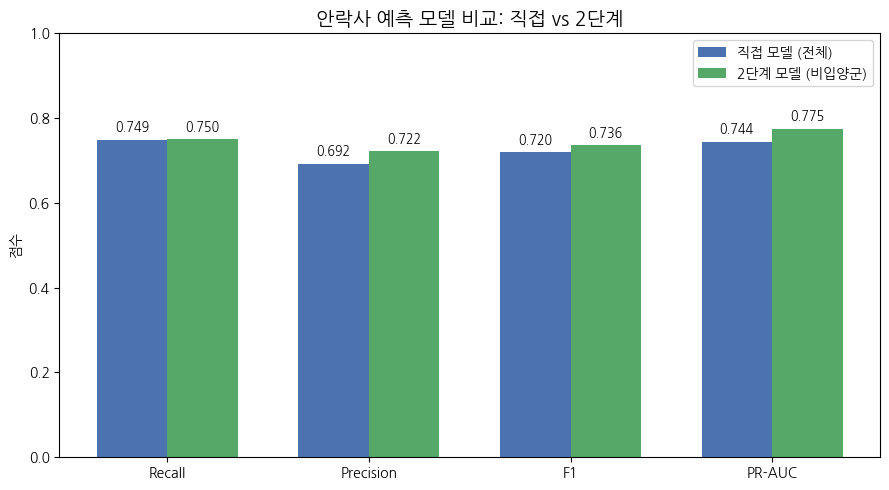

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score

direct = [
    recall_score(y_euth_test, y_euth_pred),
    precision_score(y_euth_test, y_euth_pred),
    f1_score(y_euth_test, y_euth_pred),
    average_precision_score(y_euth_test, y_euth_proba),
]
stage2 = [
    recall_score(y_euth_test_stage2, y_pred_s2),
    precision_score(y_euth_test_stage2, y_pred_s2),
    f1_score(y_euth_test_stage2, y_pred_s2),
    average_precision_score(y_euth_test_stage2, y_proba_s2),
]

metrics = ['Recall', 'Precision', 'F1', 'PR-AUC']
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, direct, width, label='직접 모델 (전체)', color='#4C72B0')
plt.bar(x + width/2, stage2, width, label='2단계 모델 (비입양군)', color='#55A868')
plt.xticks(x, metrics)
plt.ylabel('점수')
plt.title('안락사 예측 모델 비교: 직접 vs 2단계', fontsize=14, fontweight='bold')
plt.legend()
plt.ylim(0, 1)
for i, (d, s) in enumerate(zip(direct, stage2)):
    plt.text(i - width/2, d + 0.02, f'{d:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, s + 0.02, f'{s:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("euth_model_comparison.png", dpi=120)
plt.show()

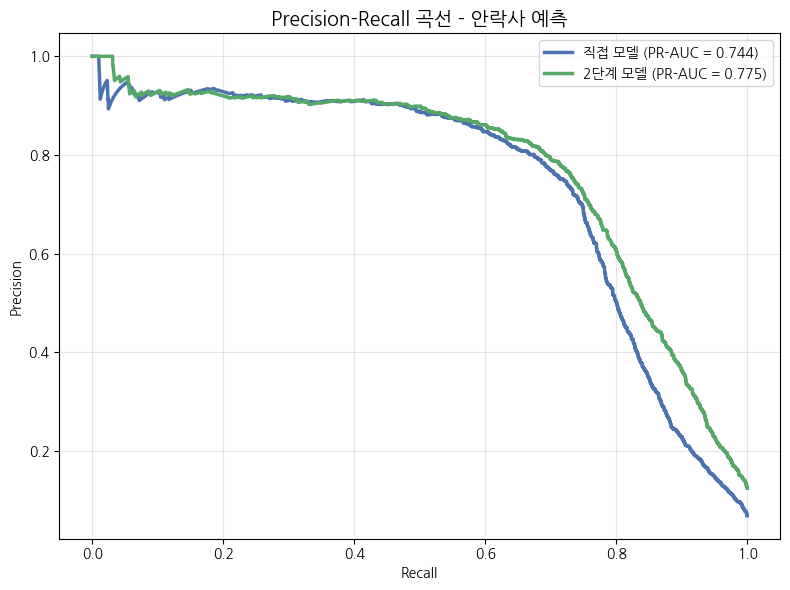

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 직접 모델
prec_d, rec_d, _ = precision_recall_curve(y_euth_test, y_euth_proba)
ap_d = average_precision_score(y_euth_test, y_euth_proba)
plt.plot(rec_d, prec_d, color='#4C72B0', linewidth=2.5,
         label=f'직접 모델 (PR-AUC = {ap_d:.3f})')

# 2단계 모델
prec_s, rec_s, _ = precision_recall_curve(y_euth_test_stage2, y_proba_s2)
ap_s = average_precision_score(y_euth_test_stage2, y_proba_s2)
plt.plot(rec_s, prec_s, color='#55A868', linewidth=2.5,
         label=f'2단계 모델 (PR-AUC = {ap_s:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall 곡선 - 안락사 예측', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("euth_pr_curve.png", dpi=120)
plt.show()